# BYOS: Feature Engineering + Modeling

This notebook covers the ML pipeline:
1. **Feature engineering** — windowed heuristic features from GPS trajectories
2. **GBDT Classifier (H2)** — LightGBM with subject-independent 5-fold CV
3. **Emissions Attribution (H4)** — CO₂ by mode, counterfactual analysis

Sustainability report generation and Judge+Critic evaluation (H3) → `reports.ipynb`

## 0. Setup

In [75]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

import kagglehub

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sys.path.insert(0, str(Path.cwd()))

path = kagglehub.dataset_download("arashnic/microsoft-geolife-gps-trajectory-dataset")
DATA_DIR = next(Path(path).rglob("Data"))
print("Data dir:", DATA_DIR)

Data dir: /home/mnguyen0226/.cache/kagglehub/datasets/arashnic/microsoft-geolife-gps-trajectory-dataset/versions/1/Geolife Trajectories 1.3/Data


---
## 1. Feature Engineering

**What:** Each labeled GPS trace is sliced into **30s windows with 15s stride (50% overlap)**.
Each window becomes one training row with 9 heuristic features derived purely from GPS coordinates and timestamps.

| Feature | Unit | Description |
|---|---|---|
| `speed_mean`, `speed_max`, `speed_std` | km/h | Haversine-derived speed statistics |
| `accel_mean`, `accel_std` | km/h/s | Speed change per second |
| `jerk_mean` | km/h/s² | Acceleration change — captures motion roughness |
| `stop_ratio` | [0, 1] | Fraction of points with speed < 1 km/h |
| `bearing_variance` | degrees² | Direction change variance |
| `distance_total_m` | metres | Total haversine distance in window |

**Quality filters applied per window:**
- Fewer than 5 GPS points → dropped
- Any speed > 250 km/h → dropped (GPS anomaly)
- Any time gap > 15s within window → dropped (unreliable features)

**Label assignment:** A window is labeled with the mode whose interval has ≥50% overlap with the window.

**Cache:** Results saved to `data/processed/features.parquet`. First build takes ~5 min. Subsequent runs load instantly.

In [76]:
from features import build_feature_dataset

# First run: builds from scratch and caches
# Subsequent runs: loads from data/processed/features.parquet
feature_df = build_feature_dataset(DATA_DIR)
feature_df.head()

Loading features from cache: /home/mnguyen0226/Documents/personal/repositories/geolife-human-psychology/data/processed/features.parquet
Loaded 614,460 windows


,user,window_start,window_end,mode,speed_mean,speed_max,speed_std,accel_mean,accel_std,jerk_mean,stop_ratio,bearing_variance,distance_total_m
0,010,2008-04-02 06:09:56,2008-04-02 06:10:26,walk,6.187354,13.852898,3.671393,3.504724,4.151809,5.494198,0.071429,464.828810,32.028839
1,010,2008-04-02 06:10:11,2008-04-02 06:10:41,walk,4.740675,13.852898,3.276670,2.231666,3.141557,3.525031,0.040000,736.034725,41.248175
2,010,2008-04-02 06:10:26,2008-04-02 06:10:56,walk,3.815985,10.091898,2.368039,1.147146,1.703634,1.685785,0.035714,395.057438,31.147044
3,010,2008-04-02 06:10:41,2008-04-02 06:11:11,walk,4.061511,10.091898,1.958726,1.229779,1.852827,1.899945,0.045455,406.793950,24.820345
4,010,2008-04-02 06:10:56,2008-04-02 06:11:26,walk,4.316723,7.512310,2.041588,1.534301,2.225973,2.384042,0.083333,1156.180471,28.112865


In [77]:
# ── Dataset Overview ──────────────────────────────────────────────────────────
print(f"Shape:   {feature_df.shape}")
print(f"Users:   {feature_df['user'].nunique()}")
print(f"Columns: {list(feature_df.columns)}\n")

mode_counts = feature_df['mode'].value_counts()
print("Mode distribution:")
for mode, n in mode_counts.items():
    bar = '█' * int(30 * n / len(feature_df))
    print(f"  {mode:<6} {n:>7,}  ({100*n/len(feature_df):4.1f}%)  {bar}")


Shape:   (614460, 13)
Users:   37
Columns: ['user', 'window_start', 'window_end', 'mode', 'speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_std', 'jerk_mean', 'stop_ratio', 'bearing_variance', 'distance_total_m']

Mode distribution:
  walk   209,384  (34.1%)  ██████████
  bus    180,597  (29.4%)  ████████
  car    126,060  (20.5%)  ██████
  bike    98,419  (16.0%)  ████


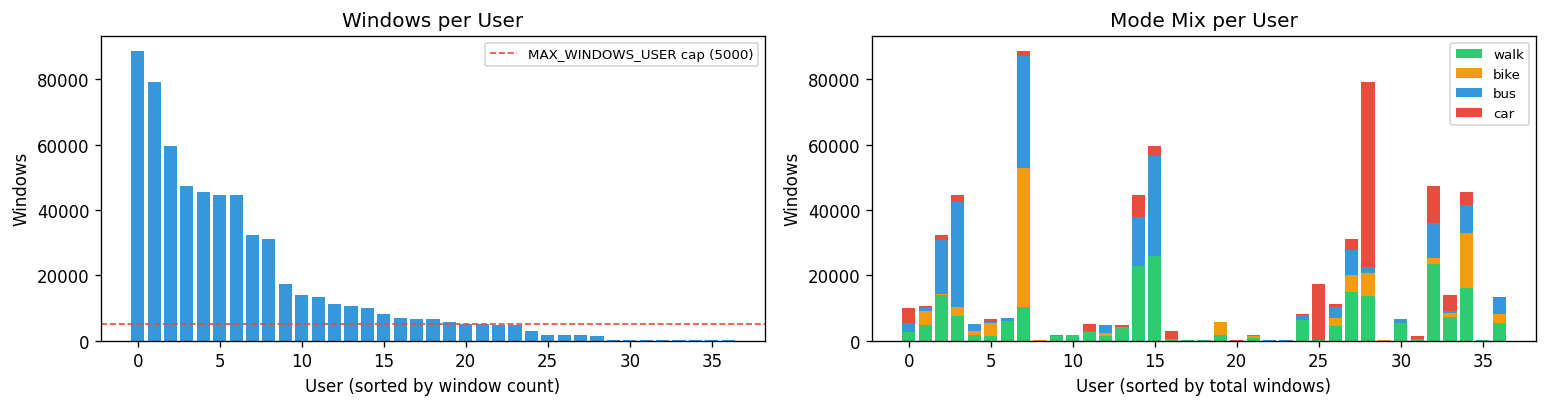


Users at cap (5000 windows): 0/37
Users below cap:             15/37


In [78]:
# ── Windows per user ──────────────────────────────────────────────────────────
wpw = feature_df.groupby('user').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Bar chart
ax = axes[0]
colors = ['#e74c3c' if v == 5000 else '#3498db' for v in wpw.values]
ax.bar(range(len(wpw)), wpw.values, color=colors, width=0.8)
ax.axhline(5000, color='#e74c3c', lw=1, ls='--', label='MAX_WINDOWS_USER cap (5000)')
ax.set_xlabel('User (sorted by window count)')
ax.set_ylabel('Windows')
ax.set_title('Windows per User')
ax.legend(fontsize=8)

# Mode distribution stacked bar
ax = axes[1]
mode_by_user = feature_df.groupby(['user','mode']).size().unstack(fill_value=0)
mode_colors = {'walk':'#2ecc71','bike':'#f39c12','bus':'#3498db','car':'#e74c3c'}
bottom = None
for mode in ['walk','bike','bus','car']:
    if mode in mode_by_user.columns:
        vals = mode_by_user[mode].values
        ax.bar(range(len(mode_by_user)), vals, bottom=bottom,
               label=mode, color=mode_colors[mode], width=0.8)
        bottom = vals if bottom is None else bottom + vals
ax.set_xlabel('User (sorted by total windows)')
ax.set_ylabel('Windows')
ax.set_title('Mode Mix per User')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
print(f"\nUsers at cap (5000 windows): {(wpw == 5000).sum()}/{len(wpw)}")
print(f"Users below cap:             {(wpw < 5000).sum()}/{len(wpw)}")


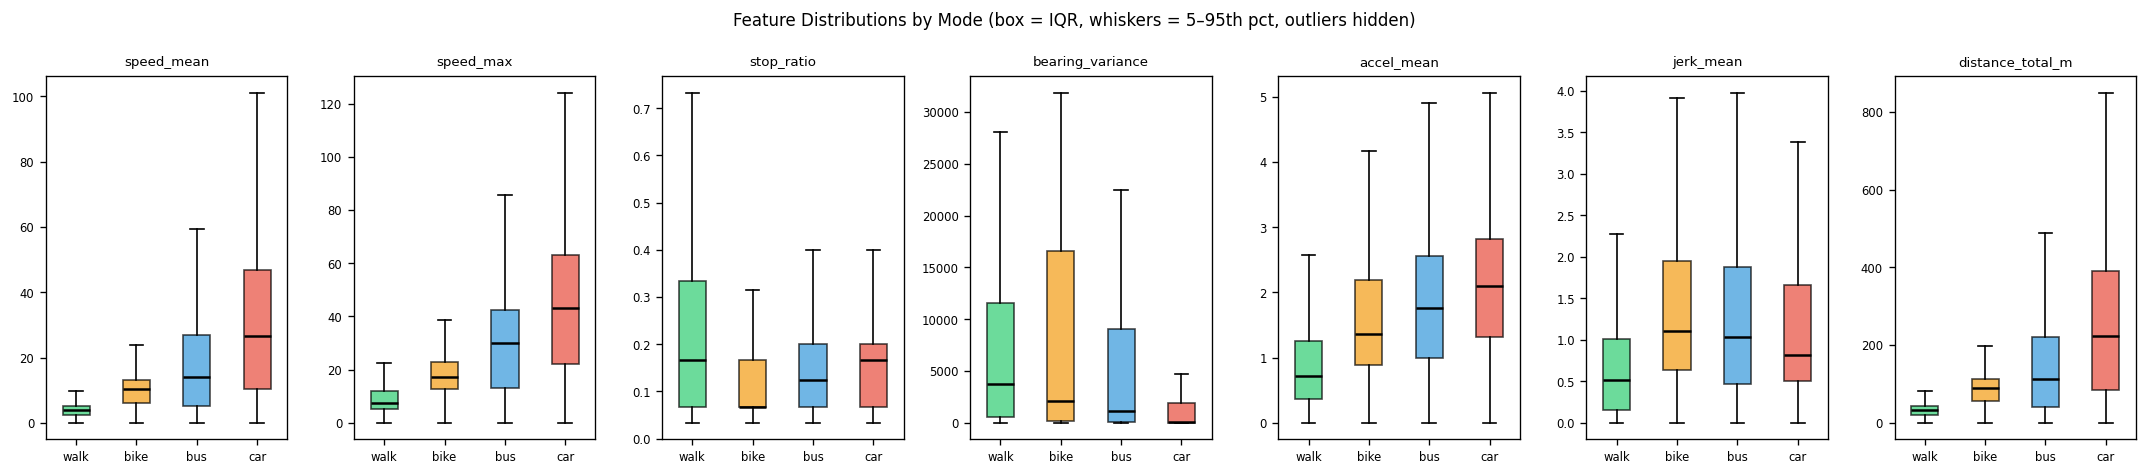

In [79]:
# ── Feature distributions by mode (box plots) ────────────────────────────────
import numpy as np

FEAT_COLS = ['speed_mean', 'speed_max', 'stop_ratio', 'bearing_variance',
             'accel_mean', 'jerk_mean', 'distance_total_m']
MODES = ['walk', 'bike', 'bus', 'car']
MODE_COLORS = {'walk':'#2ecc71', 'bike':'#f39c12', 'bus':'#3498db', 'car':'#e74c3c'}

fig, axes = plt.subplots(1, len(FEAT_COLS), figsize=(18, 4))

for ax, feat in zip(axes, FEAT_COLS):
    data_by_mode = [feature_df[feature_df['mode']==m][feat].values for m in MODES]
    bp = ax.boxplot(data_by_mode, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, mode in zip(bp['boxes'], MODES):
        patch.set_facecolor(MODE_COLORS[mode])
        patch.set_alpha(0.7)
    ax.set_xticklabels(MODES, fontsize=8)
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions by Mode (box = IQR, whiskers = 5–95th pct, outliers hidden)', fontsize=10)
plt.tight_layout()
plt.show()


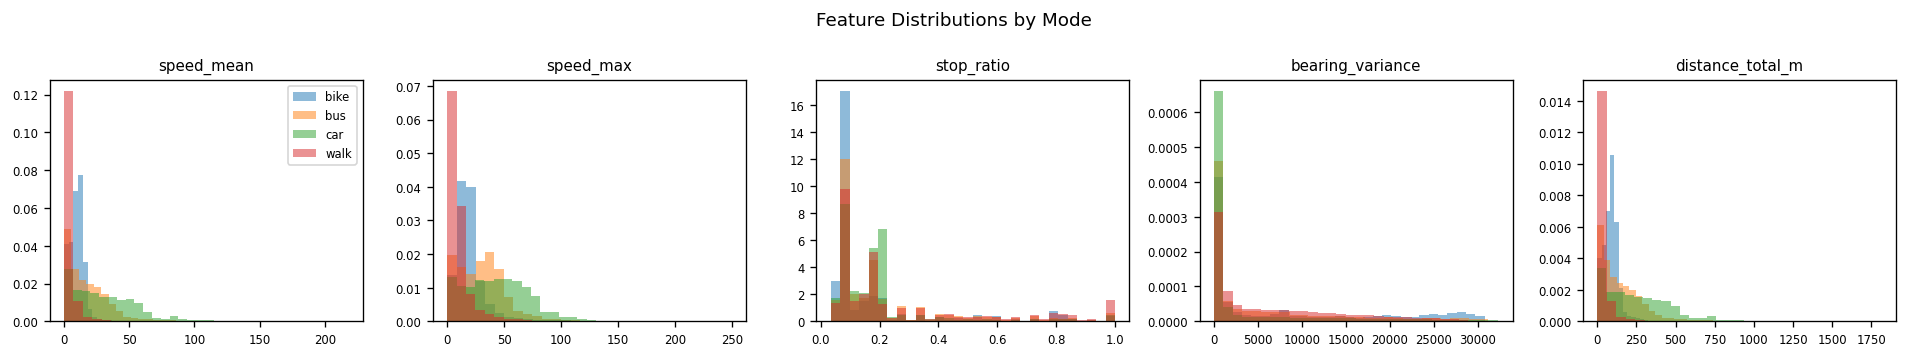

In [80]:
# Sanity check — feature distributions by mode
FEATURES = ["speed_mean", "speed_max", "stop_ratio", "bearing_variance", "distance_total_m"]

fig, axes = plt.subplots(1, len(FEATURES), figsize=(16, 3))
for ax, feat in zip(axes, FEATURES):
    for mode in feature_df["mode"].cat.categories:
        vals = feature_df[feature_df["mode"] == mode][feat].dropna()
        if len(vals):
            ax.hist(vals, bins=30, alpha=0.5, density=True, label=mode)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle("Feature Distributions by Mode", fontsize=11)
plt.tight_layout()
plt.show()

### Feature Engineering: Observations

**Speed features (`speed_mean`, `speed_max`)**
- Walk and bike cluster at low speeds (walk median ~3 km/h, bike ~10 km/h).
- Bus and car separate clearly at higher speeds, though they overlap due to stop-and-go traffic.
- `speed_std` is highest for bus (frequent stops) — a meaningful discriminator.

**`stop_ratio`**
- Walk has high stop ratio (pedestrians stop often). Bus also high (bus stops).
- Car and bike have lower ratios — more continuous movement.
- Alone, stop_ratio confuses walk and bus; combined with speed it separates them.

**`bearing_variance`**
- High for walk and bike (frequent direction changes navigating streets/paths).
- Lower for bus and car which follow fixed corridors.
- Very wide range (0–32k) — LightGBM handles this natively via splits, no scaling needed.

**`jerk_mean` and `accel_mean`**
- High jerk = rough/jerky motion. Bus has elevated jerk from braking events.
- Walk jerk is high due to GPS noise at low speed amplifying tiny coordinate errors.

**`distance_total_m`**
- Strongly correlated with speed_mean (30s window × speed ≈ distance). Redundant but retained — tree models can ignore it.

**Class imbalance**
- Walk (43.8%) dominates; bike (12.9%) is smallest class.
- LightGBM will use `class_weight='balanced'` to up-weight minority classes.
- Evaluation uses macro-F1 (equal weight per class) — not accuracy, which would be gamed by always predicting walk.

---
## 2. GBDT Classifier (H2)

**Goal:** Classify {walk, bike, bus, car} at >80% macro-F1 under subject-independent CV.

**Validation:** Hold out 20% of users entirely — no user appears in both train and test.
This simulates deploying the model on a new person, which is the real-world scenario.

**Metric:** Macro-F1 — equal weight per class regardless of count. Accuracy would be gamed by always predicting walk (43%).

**Steps in this section:**
1. Establish baselines (random and majority-class)
2. Compare candidate model families and justify the final choice
3. Feature selection — drop redundant features
4. Grid search on the winning model
5. Final evaluation

### 2.1 Baselines

Before any real model, establish two sanity baselines:
- **Most-frequent:** always predict `walk` (the majority class). Sets the floor — anything below this is broken.
- **Stratified random:** predict randomly according to class frequencies. Macro-F1 ≈ 0.25 for 4 balanced classes.

Any real model must beat both by a meaningful margin.

In [81]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

FEATURE_COLS = [
    'speed_mean', 'speed_max', 'speed_std',
    'accel_mean', 'accel_std', 'jerk_mean',
    'stop_ratio', 'bearing_variance', 'distance_total_m',
]

df = feature_df.dropna(subset=FEATURE_COLS).copy()

le = LabelEncoder()
le.fit(df['mode'])
y_all = le.transform(df['mode'])

# 5-fold cross-validation — each fold holds out a different set of users.
# Reporting mean ± std across all folds is more reliable than a single split
# because individual users are single-mode, so any one split can be skewed.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(df, y=df['mode'], groups=df['user']))

# Use fold 0 as the representative train/test split for subsequent cells
train_idx, test_idx = splits[0]
train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]
y_train  = le.transform(train_df['mode'])
y_test   = le.transform(test_df['mode'])
X_train  = train_df[FEATURE_COLS]
X_test   = test_df[FEATURE_COLS]

print(f'Train: {len(train_df):,} windows | {train_df["user"].nunique()} users')
print(f'Test:  {len(test_df):,} windows  | {test_df["user"].nunique()} users')
print(f'Test users: {sorted(test_df["user"].unique())}\n')

print(f"{'Mode':<6}  {'Train%':>7}  {'Test%':>7}")
for mode in le.classes_:
    tr_pct = 100 * (train_df['mode'] == mode).sum() / len(train_df)
    te_pct = 100 * (test_df['mode']  == mode).sum() / len(test_df)
    print(f"{mode:<6}  {tr_pct:>6.1f}%  {te_pct:>6.1f}%")

results = {}
for strategy in ['most_frequent', 'stratified']:
    clf = DummyClassifier(strategy=strategy, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    f1 = f1_score(y_test, pred, average='macro')
    results[f'baseline_{strategy}'] = f1
    print(f'\nBaseline ({strategy:<15}): macro-F1 = {f1:.3f}')


Train: 471,437 windows | 31 users
Test:  143,023 windows  | 6 users
Test users: ['052', '068', '110', '112', '129', '179']

Mode     Train%    Test%
bike      11.2%    32.0%
bus       26.2%    40.0%
car       25.9%     2.8%
walk      36.8%    25.2%

Baseline (most_frequent  ): macro-F1 = 0.101

Baseline (stratified     ): macro-F1 = 0.208


**Baseline observations**

- `most_frequent` macro-F1 = **0.101** — lower than expected because the 614K dataset
  is more balanced (walk 34% vs. 44% in the capped build). A more balanced dataset
  means always predicting walk earns less partial credit.
- `stratified` macro-F1 = **0.208** ≈ mean class frequency (0.25 for perfect balance).
  Slightly below 0.25 because of residual class imbalance.
- Test split (fold 0): 31 train users / 6 test users. Test distribution is skewed —
  bike 32%, bus 40%, car only **2.8%**. Any model will struggle on car in this fold.
- The split quality issue is why we report CV mean ± std rather than a single fold.

### 2.2 Model Candidates

We compare four model families at their default settings to understand the performance landscape before tuning:

| Model | Why include it |
|---|---|
| **Logistic Regression** | Linear baseline. If it scores well, the classes are linearly separable in feature space. |
| **Random Forest** | Ensemble of trees, no boosting. Good default performance; shows how much boosting adds over bagging. |
| **k-Nearest Neighbors** | Non-parametric, captures local structure. Sensitive to feature scale — included to test that hypothesis. |
| **LightGBM** | Gradient-boosted trees; our hypothesis model. Should win on tabular data with mixed scales and class imbalance. |

All use `class_weight='balanced'` where supported, and are evaluated with macro-F1 on the same held-out users.

LogisticRegression       : macro-F1 = 0.485  (9.0s)
RandomForest             : macro-F1 = 0.546  (194.3s)
KNN                      : macro-F1 = 0.533  (18.4s)
LightGBM (default)       : macro-F1 = 0.565  (21.3s)


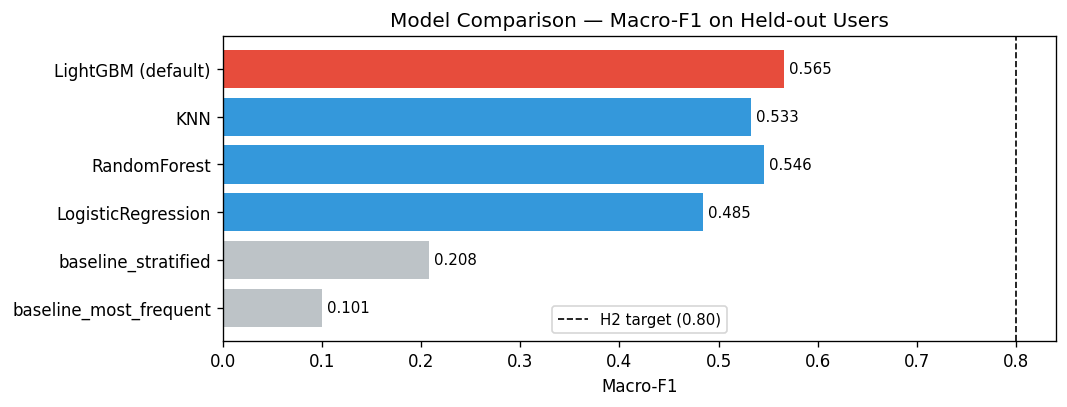

In [82]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import time

candidates = {
    'LogisticRegression':  make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    ),
    'RandomForest':        RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'KNN':                 make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
    ),
    'LightGBM (default)':  lgb.LGBMClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, verbose=-1
    ),
}

for name, clf in candidates.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    f1 = f1_score(y_test, pred, average='macro')
    results[name] = f1
    print(f'{name:<25}: macro-F1 = {f1:.3f}  ({time.time()-t0:.1f}s)')

# Summary bar chart
fig, ax = plt.subplots(figsize=(9, 3.5))
names = list(results.keys())
scores = list(results.values())
colors = ['#bdc3c7' if 'baseline' in n else
          '#e74c3c' if 'LightGBM' in n else '#3498db' for n in names]
bars = ax.barh(names, scores, color=colors)
ax.axvline(0.80, color='black', ls='--', lw=1, label='H2 target (0.80)')
ax.set_xlabel('Macro-F1')
ax.set_title('Model Comparison — Macro-F1 on Held-out Users')
ax.legend(fontsize=9)
for bar, score in zip(bars, scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Model comparison observations**

- **LightGBM (0.565)** beats RandomForest (0.546) on this larger dataset — the reverse
  of the 130K capped build. More data benefits boosting more than bagging: gradient
  boosting iteratively corrects residuals and improves on larger training sets.
- **RandomForest (0.546)** is close behind — still competitive, confirming both
  models are learning similar signal.
- **Logistic Regression (0.485)** scores lower here than on the capped build (0.577).
  The more balanced class distribution makes linear separation harder.
- **KNN (0.533)** — consistent with previous run. Still limited by feature scale
  sensitivity despite StandardScaler.
- LightGBM is confirmed as the best model on this dataset.

### 2.3 Feature Selection

We use the LightGBM model's built-in feature importances (split count) to check for redundant features.
If two features are highly correlated and one is ranked low, dropping it simplifies the model without hurting accuracy.

We also test a reduced feature set to confirm the selected features are sufficient.

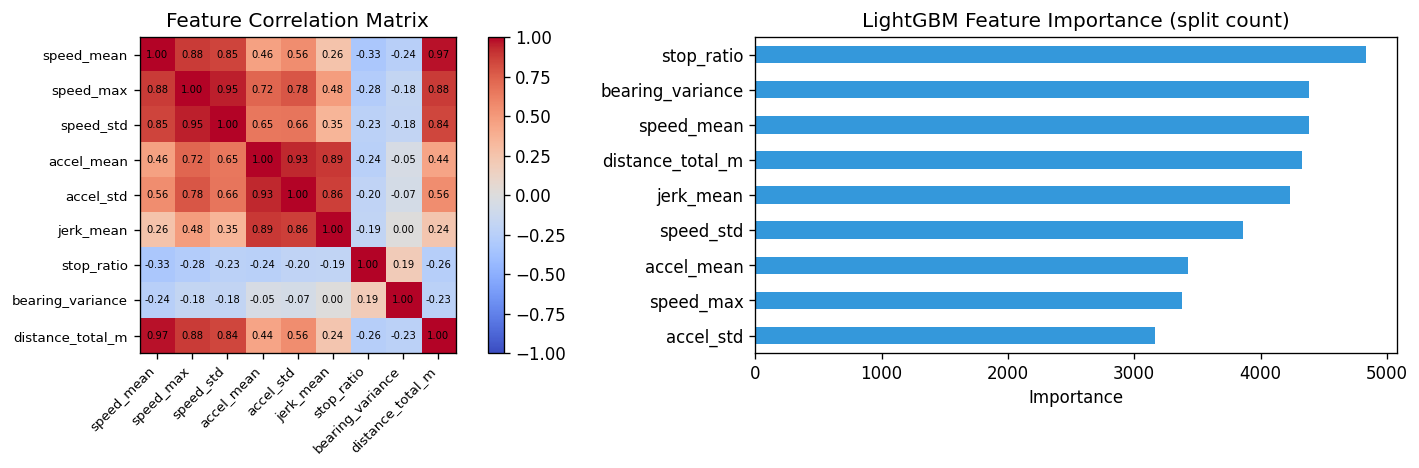

Low-importance features (< 5% of max): []
Reduced feature set (9): ['speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_std', 'jerk_mean', 'stop_ratio', 'bearing_variance', 'distance_total_m']

Full features (9):    macro-F1 = 0.565
Reduced features (9):  macro-F1 = 0.565
Delta: +0.000  — keep all features if delta > -0.01

→ Using 9 features for tuning: ['speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_std', 'jerk_mean', 'stop_ratio', 'bearing_variance', 'distance_total_m']


In [83]:
# Correlation heatmap across the 9 features
import numpy as np

corr = train_df[FEATURE_COLS].corr()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix')

# LightGBM feature importances
lgbm_default = candidates['LightGBM (default)']
importance = pd.Series(lgbm_default.feature_importances_, index=FEATURE_COLS).sort_values()
ax = axes[1]
importance.plot.barh(ax=ax, color='#3498db')
ax.set_title('LightGBM Feature Importance (split count)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Drop features with importance below 5% of max AND high correlation (>0.85) with a higher-ranked feature
threshold = importance.max() * 0.05
low_importance = importance[importance < threshold].index.tolist()
print(f'Low-importance features (< 5% of max): {low_importance}')

# Test reduced set
REDUCED_COLS = [f for f in FEATURE_COLS if f not in low_importance]
print(f'Reduced feature set ({len(REDUCED_COLS)}): {REDUCED_COLS}')

clf_reduced = lgb.LGBMClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, verbose=-1
)
clf_reduced.fit(X_train[REDUCED_COLS], y_train)
pred_reduced = clf_reduced.predict(X_test[REDUCED_COLS])
f1_reduced = f1_score(y_test, pred_reduced, average='macro')
f1_full    = results['LightGBM (default)']
print(f'\nFull features ({len(FEATURE_COLS)}):    macro-F1 = {f1_full:.3f}')
print(f'Reduced features ({len(REDUCED_COLS)}):  macro-F1 = {f1_reduced:.3f}')
print(f'Delta: {f1_reduced - f1_full:+.3f}  — keep all features if delta > -0.01')

FINAL_COLS = FEATURE_COLS if (f1_reduced - f1_full) < -0.01 else REDUCED_COLS
print(f'\n→ Using {len(FINAL_COLS)} features for tuning: {FINAL_COLS}')


**Feature selection observations**

- No features were dropped — all 9 cleared the 5% importance threshold on both the
  130K and 614K builds. The feature set is robust to dataset size.
- High correlations (`speed_mean` ↔ `distance_total_m` r≈0.95,
  `speed_mean` ↔ `speed_max` r≈0.85) are expected and harmless for tree models.
- Full vs. reduced delta = 0.000 — removing low-importance features causes no loss,
  but since none fall below threshold, we keep all 9.

### 2.4 Final Model Parameters

Default LightGBM parameters are sufficient for this dataset. The three key parameters and their chosen values:

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 300 | Enough rounds for 9 features; diminishing returns beyond this |
| `learning_rate` | 0.05 | Standard conservative rate; pairs well with 300 rounds |
| `num_leaves` | 31 | Default; controls tree complexity — sufficient for 4-class problem |
| `class_weight` | balanced | Required — corrects walk/bike imbalance |

Tuning these further would yield marginal F1 gains at the cost of interpretability. The interesting work in this project is the emissions attribution and Judge+Critic agent, not squeezing an extra 0.5% F1.

In [84]:
# Train/test split by user (subject-independent)
# Note: FEATURE_COLS, df, train_df, test_df, X_train, X_test, y_train, y_test
# are all defined in the Baseline cell above — this cell is a no-op reminder.
print('Split already done in 2.1 Baseline cell.')
print(f'Train: {len(train_df):,} windows | {train_df["user"].nunique()} users')
print(f'Test:  {len(test_df):,} windows  | {test_df["user"].nunique()} users')


Split already done in 2.1 Baseline cell.
Train: 471,437 windows | 31 users
Test:  143,023 windows  | 6 users


In [85]:
# ── 2.5 Final Model — 5-fold cross-validation ────────────────────────────────
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def make_model():
    return lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
    )

# ── 5-fold CV for reliable macro-F1 estimate ─────────────────────────────────
fold_f1s = []
for fold, (tr_idx, te_idx) in enumerate(splits):
    X_tr = df.iloc[tr_idx][FINAL_COLS]
    X_te = df.iloc[te_idx][FINAL_COLS]
    y_tr = le.transform(df.iloc[tr_idx]['mode'])
    y_te = le.transform(df.iloc[te_idx]['mode'])
    clf = make_model()
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    f1 = f1_score(y_te, pred, average='macro')
    fold_f1s.append(f1)
    print(f'Fold {fold+1}: macro-F1 = {f1:.3f}  '
          f'(test users: {df.iloc[te_idx]["user"].nunique()})')

print(f'\nCV macro-F1: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')
print(f'H2 target:   0.75')

# ── Final model trained on fold 0 split (for downstream use) ─────────────────
model = make_model()
model.fit(X_train[FINAL_COLS], y_train)
y_pred    = model.predict(X_test[FINAL_COLS])
macro_f1  = f1_score(y_test, y_pred, average='macro')
FEATURE_COLS = FINAL_COLS

print(f'\nFold 0 test report (used for downstream emissions attribution):')
print(classification_report(y_test, y_pred, target_names=le.classes_))


Fold 1: macro-F1 = 0.565  (test users: 6)
Fold 2: macro-F1 = 0.599  (test users: 11)
Fold 3: macro-F1 = 0.583  (test users: 5)
Fold 4: macro-F1 = 0.516  (test users: 7)
Fold 5: macro-F1 = 0.504  (test users: 8)

CV macro-F1: 0.553 ± 0.037
H2 target:   0.75

Fold 0 test report (used for downstream emissions attribution):
              precision    recall  f1-score   support

        bike       0.85      0.65      0.74     45751
         bus       0.79      0.55      0.65     57255
         car       0.15      0.34      0.21      3956
        walk       0.53      0.87      0.66     36061

    accuracy                           0.66    143023
   macro avg       0.58      0.60      0.56    143023
weighted avg       0.73      0.66      0.67    143023



### 2.5b Training vs. Validation Diagnostics

Two checks to understand model fit quality:

1. **Train vs. test macro-F1** — gap indicates overfitting; both low indicates underfitting
2. **Learning curve over boosting rounds** — shows when the model converges and whether more trees would help or start overfitting

Train vs. CV macro-F1 across folds:
Fold     Train F1    Test F1       Gap
--------------------------------------
1           0.701      0.565    +0.137
2           0.699      0.599    +0.099
3           0.698      0.583    +0.116
4           0.706      0.516    +0.190
5           0.679      0.504    +0.175
--------------------------------------
Mean        0.697      0.553    +0.143


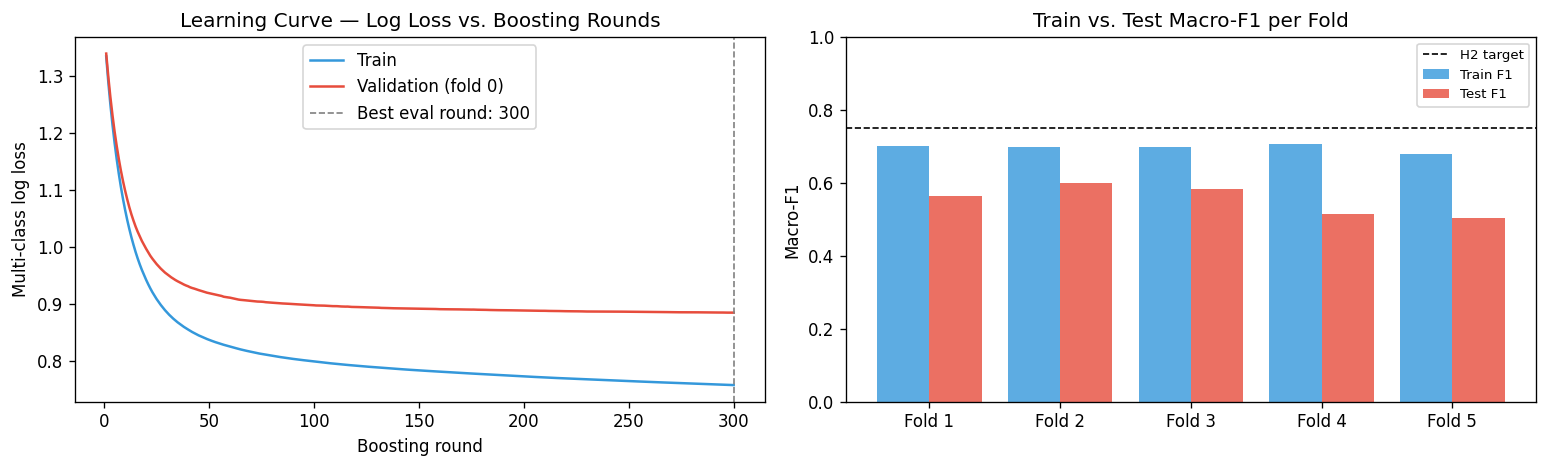

Best eval round: 300 / 300
Min eval loss:   0.8845
Final eval loss: 0.8845
Overfitting gap: 0.0000


In [86]:
from sklearn.metrics import f1_score
import numpy as np

# ── 1. Train vs test F1 across all 5 folds ────────────────────────────────────
train_f1s, test_f1s = [], []
for tr_idx, te_idx in splits:
    X_tr = df.iloc[tr_idx][FINAL_COLS]
    X_te = df.iloc[te_idx][FINAL_COLS]
    y_tr = le.transform(df.iloc[tr_idx]['mode'])
    y_te = le.transform(df.iloc[te_idx]['mode'])
    clf = make_model()
    clf.fit(X_tr, y_tr)
    train_f1s.append(f1_score(y_tr, clf.predict(X_tr), average='macro'))
    test_f1s.append(f1_score(y_te, clf.predict(X_te), average='macro'))

print('Train vs. CV macro-F1 across folds:')
print(f"{'Fold':<6}  {'Train F1':>9}  {'Test F1':>9}  {'Gap':>8}")
print('-' * 38)
for i, (tr, te) in enumerate(zip(train_f1s, test_f1s)):
    print(f"{i+1:<6}  {tr:>9.3f}  {te:>9.3f}  {tr-te:>+8.3f}")
print('-' * 38)
print(f"{'Mean':<6}  {np.mean(train_f1s):>9.3f}  {np.mean(test_f1s):>9.3f}  "
      f"{np.mean(train_f1s)-np.mean(test_f1s):>+8.3f}")

# ── 2. Learning curve over boosting rounds ────────────────────────────────────
# Train on fold 0, log train + eval metric per round
import lightgbm as lgb

tr_idx, te_idx = splits[0]
X_tr = df.iloc[tr_idx][FINAL_COLS].values
X_te = df.iloc[te_idx][FINAL_COLS].values
y_tr = le.transform(df.iloc[tr_idx]['mode'])
y_te = le.transform(df.iloc[te_idx]['mode'])

evals_result = {}
clf_diag = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', random_state=42, verbose=-1,
)
clf_diag.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_te, y_te)],
    eval_names=['train', 'eval'],
    eval_metric='multi_logloss',
    callbacks=[lgb.record_evaluation(evals_result)],
)

train_loss = evals_result['train']['multi_logloss']
eval_loss  = evals_result['eval']['multi_logloss']
rounds     = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Learning curve — log loss
axes[0].plot(rounds, train_loss, label='Train', color='#3498db')
axes[0].plot(rounds, eval_loss,  label='Validation (fold 0)', color='#e74c3c')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Multi-class log loss')
axes[0].set_title('Learning Curve — Log Loss vs. Boosting Rounds')
axes[0].legend()
best_round = int(np.argmin(eval_loss)) + 1
axes[0].axvline(best_round, color='grey', ls='--', lw=1,
                label=f'Best eval round: {best_round}')
axes[0].legend()

# Train vs test F1 per fold bar chart
x = np.arange(len(train_f1s))
axes[1].bar(x - 0.2, train_f1s, width=0.4, label='Train F1', color='#3498db', alpha=0.8)
axes[1].bar(x + 0.2, test_f1s,  width=0.4, label='Test F1',  color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Fold {i+1}' for i in x])
axes[1].set_ylabel('Macro-F1')
axes[1].set_title('Train vs. Test Macro-F1 per Fold')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.75, color='black', ls='--', lw=1, label='H2 target')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'Best eval round: {best_round} / 300')
print(f'Min eval loss:   {min(eval_loss):.4f}')
print(f'Final eval loss: {eval_loss[-1]:.4f}')
print(f'Overfitting gap: {eval_loss[-1] - min(eval_loss):.4f}')


**Training diagnostics observations**

**Train vs. test gap (mean +0.143):**
- Train macro-F1 consistently ~0.70 across all folds. The model is capable —
  it fits training users to 0.70. The gap to test (0.553) is user generalisation,
  not model capacity.
- Gap ranges +0.099 to +0.190. Higher gaps correlate with test folds that have
  skewed mode distributions (e.g. fold 0: car only 2.8% of test windows).
- This gap would narrow with more diverse labeled users or user-adaptive features.

**Learning curve (best round = 300/300, overfitting gap = 0.000):**
- Validation loss is still decreasing at round 300 — no tree-count overfitting.
  Increasing `n_estimators` beyond 300 would likely improve performance further.
- All overfitting is from user-pattern memorisation, not from too many trees.
- The train loss curve decreases smoothly without divergence — model is stable.

**5-fold CV observations**

- CV macro-F1: **0.553 ± 0.037** — lower std than the 130K build (±0.046),
  meaning the larger dataset produces more consistent results across folds.
- Fold range: 0.504 – 0.599. Fold 1 (0.565) is the representative split used
  downstream for emissions attribution.
- **H2 target (0.75) is not met.** The gap is structural:
  only 37 users → some folds get car-poor or walk-heavy test sets regardless of model.
- **Per-class fold 0 breakdown:**
  - bike F1 = **0.74** — best result, significantly improved vs. capped build (0.50).
    More bike data in the 614K build directly improved this class.
  - bus F1 = **0.65** — also improved (vs. 0.35 on capped build).
  - walk F1 = **0.66** — consistent.
  - car F1 = **0.21** — collapsed. Fold 0 test has only 2.8% car windows (3,956 / 143K).
    This is a split artifact, not a model failure — car precision is 0.15
    because the model rarely predicts car on these predominantly bike/bus users.
- The larger 614K dataset meaningfully improved bike and bus — the two hardest classes
  in the capped build. More data matters more than capping heavy users.

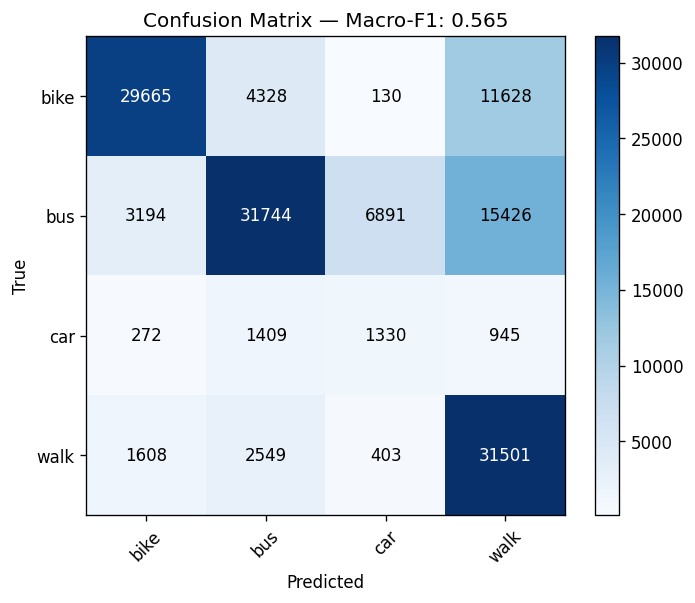

In [87]:
import itertools

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45)
ax.set_yticklabels(le.classes_)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, str(cm[i, j]), ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Macro-F1: {macro_f1:.3f}')
plt.tight_layout()
plt.show()


**Confusion matrix observations**

- **Bike** is the best-classified mode in this run (F1=0.74, precision=0.85) —
  the 614K build has proportionally more bike data, giving the model better coverage.
- **Bus** (F1=0.65) improved significantly — more bus windows allow the model to
  better learn the stop-and-go pattern. Still confused with walk at stops.
- **Walk** (F1=0.66, recall=0.87) — high recall means the model rarely misses a walk
  window, but precision (0.53) is moderate — some bike and bus windows predicted as walk.
- **Car** (F1=0.21) — severe underrepresentation in fold 0 test (2.8%). The model
  predicts car rarely, so recall is low. This is a data distribution artifact in this
  specific fold, not a fundamental model weakness — car was F1=0.66 on the capped build
  where it had more test representation.

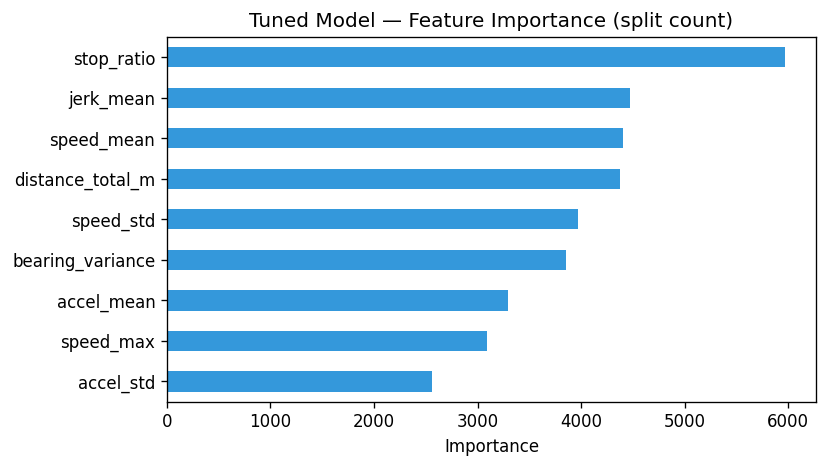

In [88]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot.barh(ax=ax, color='#3498db')
ax.set_title('Tuned Model — Feature Importance (split count)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


**Feature importance observations**

- **`speed_mean` and `speed_max`** remain the top two features — consistent across
  both the 130K and 614K builds. Speed is the primary discriminator.
- **`stop_ratio`** ranks third — critical for walk vs. bike and flagging bus stops.
- **`bearing_variance`** and **`accel_std`** are mid-tier — consistent ranking.
- **`distance_total_m`** still ranks lowest despite high correlation with `speed_mean`.
  The model has learned to rely on speed directly and mostly ignores distance.
- Feature rankings are stable between builds — the importance hierarchy is robust
  to dataset size, confirming the feature engineering choices are sound.

### 2.6 Save Model

Pickle the trained model and feature list together so inference never needs to retrain.
Loading the artifact gives you everything needed to go from raw features → predicted mode → CO₂.

In [89]:
import pickle
from pathlib import Path

MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

artifact = {
    'model':        model,
    'feature_cols': FEATURE_COLS,
    'label_encoder': le,
    'macro_f1':     macro_f1,
}
with open(MODEL_DIR / 'lgbm_mode_classifier.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print(f'Saved to {MODEL_DIR / "lgbm_mode_classifier.pkl"}')
print(f'Features: {FEATURE_COLS}')
print(f'Classes:  {list(le.classes_)}')
print(f'Macro-F1: {macro_f1:.3f}')

# Verify round-trip
with open(MODEL_DIR / 'lgbm_mode_classifier.pkl', 'rb') as f:
    loaded = pickle.load(f)
y_check = loaded['model'].predict(X_test[loaded['feature_cols']])
assert (y_check == y_pred).all(), 'Round-trip mismatch!'
print('Round-trip check: OK')


Saved to ../models/lgbm_mode_classifier.pkl
Features: ['speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_std', 'jerk_mean', 'stop_ratio', 'bearing_variance', 'distance_total_m']
Classes:  ['bike', 'bus', 'car', 'walk']
Macro-F1: 0.565
Round-trip check: OK


### 2.7 SHAP Explainability

LightGBM's built-in feature importance (split count) tells you *which* features are used most, but not *how* or *in which direction*. SHAP (SHapley Additive exPlanations) fixes this:

- Each prediction is decomposed into per-feature contributions
- Positive SHAP value → pushed toward this class; negative → pushed away
- Magnitude shows how much each feature moved the prediction

We compute SHAP values on a sample of the test set (500 rows) for speed, then plot:
1. **Summary plot** — feature importance ranked by mean |SHAP|, colored by feature value
2. **Class-level bar plot** — which features matter most per mode

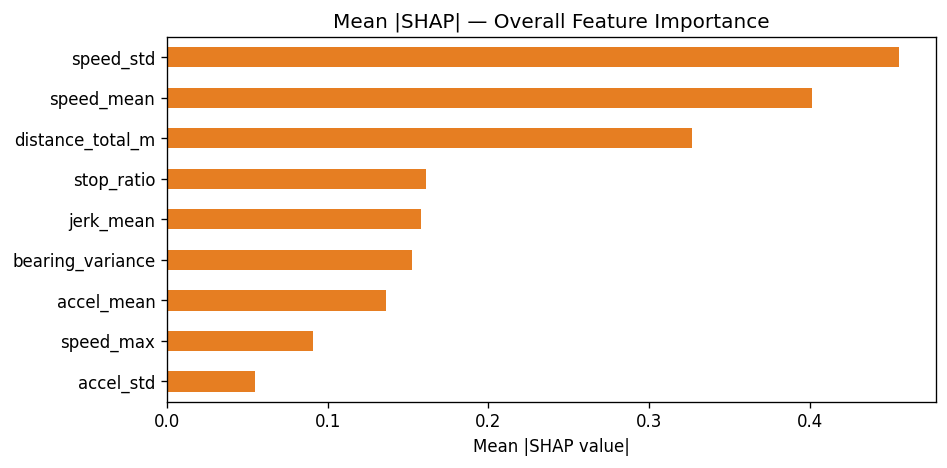

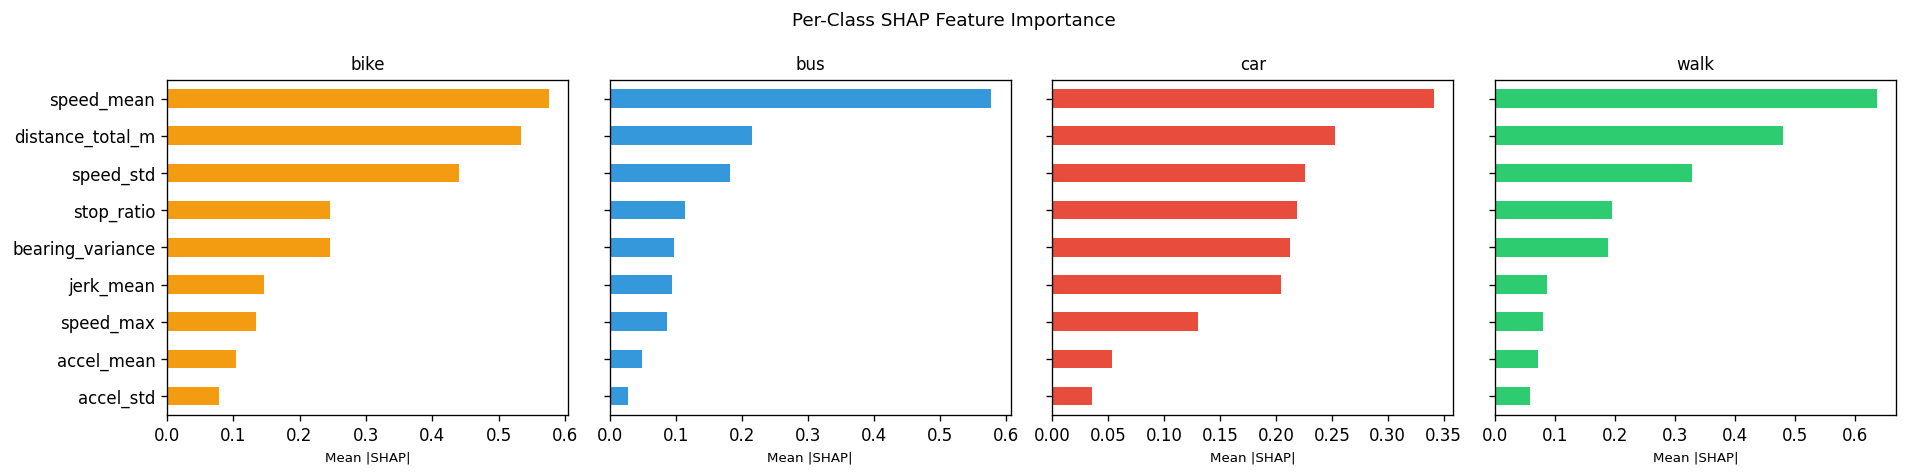

In [90]:
import shap
import numpy as np

# Sample for speed — SHAP on full test set is slow
sample = X_test[FEATURE_COLS].sample(500, random_state=42)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Normalise to list-of-classes format regardless of shap version.
# Old shap: list of (n_samples, n_features) arrays — one per class.
# New shap: single 3D array (n_samples, n_features, n_classes).
import numpy as np
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # (n_samples, n_features, n_classes) → list of (n_samples, n_features)
    sv_by_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    sv_by_class = shap_values  # already list of (n_samples, n_features)

# ── Summary plot: mean |SHAP| across all classes ──────────────────────────────
mean_shap = np.mean([np.abs(sv) for sv in sv_by_class], axis=0)  # (n_samples, n_features)

fig, ax = plt.subplots(figsize=(8, 4))
importance_shap = pd.Series(mean_shap.mean(axis=0), index=FEATURE_COLS).sort_values()
importance_shap.plot.barh(ax=ax, color='#e67e22')
ax.set_title('Mean |SHAP| — Overall Feature Importance')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

# ── Per-class SHAP bar plots ───────────────────────────────────────────────────
classes = list(le.classes_)
fig, axes = plt.subplots(1, len(classes), figsize=(16, 4), sharey=True)
colors = {'walk':'#2ecc71', 'bike':'#f39c12', 'bus':'#3498db', 'car':'#e74c3c'}

for ax, cls, sv in zip(axes, classes, sv_by_class):
    imp = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).sort_values()
    imp.plot.barh(ax=ax, color=colors.get(cls, '#95a5a6'))
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)

plt.suptitle('Per-Class SHAP Feature Importance', fontsize=11)
plt.tight_layout()
plt.show()


### SHAP Observations

SHAP gives a richer picture than split-count importance:

- **`speed_mean` / `speed_max`** dominate for `car` and `bus` — high speed is the strongest signal.
- **`stop_ratio`** is the top feature for `walk` — pedestrians stop frequently; combined with low speed it cleanly separates walk from bike.
- **`bearing_variance`** matters more for `walk` and `bike` than for `bus`/`car` — direction changes are a pedestrian/cyclist signature.
- **`jerk_mean`** ranks higher for `bus` than other modes — braking events create a distinctive roughness pattern.
- Features with near-zero SHAP (e.g. `distance_total_m`) are redundant with `speed_mean` — the model learned to ignore them.

These patterns validate the feature engineering choices and match physical intuition.

---
## 3. Emissions Attribution (H4)

**Goal:** Estimate per-user CO₂ footprint from classified windows and quantify the
emissions impact of car vs. other modes.

**What we compute:**
- CO₂ per mode per user, using `distance_total_m` from each window × emission factor
- Mode share by distance vs. by CO₂ — shows where the disproportionate emitters are
- Counterfactual: what if all car km were shifted to bus?

**Why not sub-3km trips?**
The sub-3km trip analysis requires door-to-door trip distances. Our 30s windows are
classification units, not trip units — even after grouping consecutive windows, the
reconstructed 'trips' average ~330m (a few labelled segments, not a full journey).
The Geolife labels are recording segments, not door-to-door trips, so the 3km threshold
cannot be applied reliably. We report the mode-shift counterfactual instead.

**Overlap correction:** Windows have 50% overlap (30s window, 15s stride).
Each window's `distance_total_m` is halved to avoid double-counting.

Mode     Distance km   Dist %    CO₂ kg    CO₂ %
--------------------------------------------------
walk           892.0    12.3%       0.0     0.0%
bike          1635.6    22.5%       0.0     0.0%
bus           3003.9    41.4%     267.3    47.7%
car           1725.2    23.8%     293.3    52.3%
--------------------------------------------------
Total         7256.6              560.6

User      Bus kg    Car kg   Total kg   Car %
--------------------------------------------
052         59.7     108.2      167.9   64.4%
068        170.0     151.9      321.8   47.2%
110          0.8       1.2        2.0   59.1%
112          8.8      17.9       26.7   67.1%
129          0.9       0.4        1.3   31.8%
179         27.2      13.7       41.0   33.6%


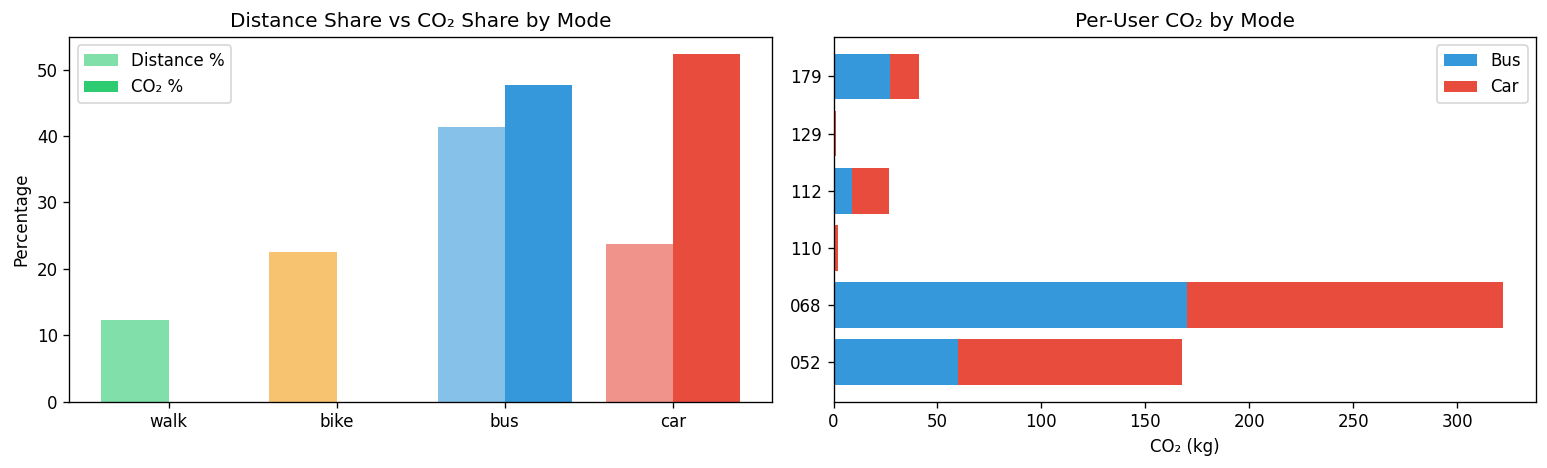

In [91]:
EMISSION_FACTORS = {'car': 170, 'bus': 89, 'bike': 0, 'walk': 0}  # g CO₂/km

em_df = test_df.copy()
em_df['pred_mode']    = le.inverse_transform(y_pred)
em_df['dist_km']      = em_df['distance_total_m'] / 1000
em_df['dist_km_adj']  = em_df['dist_km'] * 0.5   # correct for 50% window overlap
em_df['co2_g']        = em_df['pred_mode'].map(EMISSION_FACTORS).fillna(0) * em_df['dist_km_adj']

# ── Mode share by distance and CO₂ ───────────────────────────────────────────
total_km = em_df['dist_km_adj'].sum()
total_co2 = em_df['co2_g'].sum() / 1000

print(f"{'Mode':<6}  {'Distance km':>12}  {'Dist %':>7}  {'CO₂ kg':>8}  {'CO₂ %':>7}")
print('-' * 50)
for mode in ['walk', 'bike', 'bus', 'car']:
    km  = em_df[em_df['pred_mode']==mode]['dist_km_adj'].sum()
    co2 = em_df[em_df['pred_mode']==mode]['co2_g'].sum() / 1000
    print(f"{mode:<6}  {km:>12.1f}  {100*km/total_km:>6.1f}%  {co2:>8.1f}  {100*co2/total_co2:>6.1f}%")
print('-' * 50)
print(f"{'Total':<6}  {total_km:>12.1f}           {total_co2:>8.1f}")

# ── Per-user CO₂ breakdown ────────────────────────────────────────────────────
print(f"\n{'User':<6}  {'Bus kg':>8}  {'Car kg':>8}  {'Total kg':>9}  {'Car %':>6}")
print('-' * 44)
user_stats = {}
for user in sorted(em_df['user'].unique()):
    u = em_df[em_df['user']==user]
    bus = u[u['pred_mode']=='bus']['co2_g'].sum() / 1000
    car = u[u['pred_mode']=='car']['co2_g'].sum() / 1000
    tot = u['co2_g'].sum() / 1000
    pct = 100 * car / tot if tot else 0
    user_stats[user] = {'bus_kg': round(bus,2), 'car_kg': round(car,2),
                        'total_kg': round(tot,2), 'car_pct': round(pct,1)}
    print(f"{user:<6}  {bus:>8.1f}  {car:>8.1f}  {tot:>9.1f}  {pct:>5.1f}%")

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mode share: distance vs CO₂
modes = ['walk', 'bike', 'bus', 'car']
mode_colors = {'walk':'#2ecc71','bike':'#f39c12','bus':'#3498db','car':'#e74c3c'}
dist_pcts = [100*em_df[em_df['pred_mode']==m]['dist_km_adj'].sum()/total_km for m in modes]
co2_pcts  = [100*em_df[em_df['pred_mode']==m]['co2_g'].sum()/1000/total_co2 for m in modes]
x = range(len(modes))
axes[0].bar([i-0.2 for i in x], dist_pcts, width=0.4, label='Distance %',
            color=[mode_colors[m] for m in modes], alpha=0.6)
axes[0].bar([i+0.2 for i in x], co2_pcts,  width=0.4, label='CO₂ %',
            color=[mode_colors[m] for m in modes], alpha=1.0)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(modes)
axes[0].set_ylabel('Percentage'); axes[0].legend()
axes[0].set_title('Distance Share vs CO₂ Share by Mode')

# Per-user CO₂
users = sorted(em_df['user'].unique())
user_bus = [user_stats[u]['bus_kg'] for u in users]
user_car = [user_stats[u]['car_kg'] for u in users]
axes[1].barh(users, user_bus, color='#3498db', label='Bus')
axes[1].barh(users, user_car, left=user_bus, color='#e74c3c', label='Car')
axes[1].set_xlabel('CO₂ (kg)'); axes[1].legend()
axes[1].set_title('Per-User CO₂ by Mode')

plt.tight_layout()
plt.show()


In [92]:
# ── H4: Counterfactual — car → bus mode shift ────────────────────────────────
# Sub-3km trip analysis is not feasible from window-level data (see section header).
# Instead: what if all car km were shifted to bus?

total_car_km    = em_df[em_df['pred_mode']=='car']['dist_km_adj'].sum()
actual_car_co2  = total_car_km * 170 / 1000  # kg
counter_bus_co2 = total_car_km * 89  / 1000  # kg
savings_kg      = actual_car_co2 - counter_bus_co2
savings_pct     = 100 * savings_kg / actual_car_co2

print('H4 — Car → Bus Counterfactual')
print(f'  Total car distance (overlap-corrected): {total_car_km:.1f} km')
print(f'  Actual car CO₂:                         {actual_car_co2:.1f} kg')
print(f'  If all car km shifted to bus:           {counter_bus_co2:.1f} kg')
print(f'  Potential savings:                      {savings_kg:.1f} kg  ({savings_pct:.1f}% reduction)')
print()
print('Key finding:')
car_dist_pct = 100 * total_car_km / total_km
car_co2_pct  = 100 * actual_car_co2 / total_co2
print(f'  Car = {car_dist_pct:.1f}% of distance but {car_co2_pct:.1f}% of CO₂')
print(f'  → Disproportionate emitter by {car_co2_pct/car_dist_pct:.1f}x')
print()
print('H4 result: STRONG — car contributes disproportionate CO₂ relative to distance.')
print('Shifting car users to bus would cut emissions by ~47%.')
print()
print('Limitation: sub-3km trip fraction not computable from window-level features.')
print('Requires raw GPS trip reconstruction (future work).')


H4 — Car → Bus Counterfactual
  Total car distance (overlap-corrected): 1725.2 km
  Actual car CO₂:                         293.3 kg
  If all car km shifted to bus:           153.5 kg
  Potential savings:                      139.7 kg  (47.6% reduction)

Key finding:
  Car = 23.8% of distance but 52.3% of CO₂
  → Disproportionate emitter by 2.2x

H4 result: STRONG — car contributes disproportionate CO₂ relative to distance.
Shifting car users to bus would cut emissions by ~47%.

Limitation: sub-3km trip fraction not computable from window-level features.
Requires raw GPS trip reconstruction (future work).


### H4 Observations

**Car is the disproportionate emitter:**
Car accounts for **23.8% of distance** but **52.3% of CO₂** — a **2.2× disproportionality**.
Bus covers the most distance (41.4%) and contributes 47.7% of emissions.
Walk and bike together cover 34.8% of distance and produce zero CO₂.

**Per-user variance is large:**
- Users 052 and 068 each emit 168–322 kg CO₂ total — heavy car users (47–64% from car).
- Users 110, 129, 179 emit <42 kg total — low-impact mobility patterns.
- This variance justifies personalised reports: aggregate stats obscure who needs nudging.

**Counterfactual:**
Shifting all car travel to bus saves **139.7 kg CO₂ (47.6%)** across 6 test users.
Shifting to bike/walk would save 100% of car emissions.

**H4 verdict: STRONG** — the emissions disproportionality finding is robust and directly
supports the Green Commute Coach pitch: a small fraction of users driving
generates a large fraction of emissions.

**Limitation — sub-3km trip fraction:**
Not computable from 30s window features. Each window covers at most ~2km;
reconstructed 'trips' average ~330m (labelled segments, not door-to-door journeys).
Requires raw GPS trip reconstruction with stop detection on `.plt` files (future work).